# 04 – Multiple Lineare Regression

Erstes "echtes" ML-Modell nach den naiven Baselines.  
Zwei Varianten werden verglichen:

| Modell | Features |
|---|---|
| **Model A** | Strahlung + Zeit + Wetter (8 Features, kein Lag) |
| **Model B** | + Vortagswert `Solarproduktion_lag_96` (9 Features) |

**Forschungshypothesen:**
- **H2:** Wetter- und Strahlungsfeatures verbessern RMSE gegenüber Persistence
- **H3:** Vortagswert (lag₉₆) trägt signifikant zur Genauigkeit bei
- **H4:** (Ausblick) Nichtlineare Modelle übertreffen lineare Regression

## 0 · Setup

In [14]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data.preprocessing import (
    load_pv_data, load_weather_data, load_irradiance_data,
    merge_features,
)
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import (
    add_time_features, add_lag_features, add_irradiance_features,
)
from src.models.baseline import train_linear_baseline, predict
from src.evaluation.metrics import evaluate, evaluate_by_season, persistence_forecast

P_NOM       = 13_500.0
TARGET      = "Solarproduktion"
RESULTS_DIR = Path("../results/04_linear_regression")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_A = [
    "ghi_cloudy_sky", "clear_sky_index",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "temperature_2m", "cloud_cover_low",
]
FEATURES_B = FEATURES_A + ["Solarproduktion_lag_96"]

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Daten laden & mergen

In [15]:
pv_df  = load_pv_data()
w_df   = load_weather_data()
irr_df = load_irradiance_data()

df = merge_features(pv_df, w_df, irr_df)
print(f"Shape nach Merge: {df.shape}")
df[["timestamp", TARGET, "ghi_cloudy_sky", "temperature_2m", "cloud_cover_low"]].head(3)

Shape nach Merge: (113896, 22)


,timestamp,Solarproduktion,ghi_cloudy_sky,temperature_2m,cloud_cover_low
0,2022-02-07 14:00:00,192,NaN,4.1,13
1,2022-02-07 14:15:00,206,NaN,4.1,13
2,2022-02-07 14:30:00,206,NaN,4.1,13


## 2 · Feature Engineering

Warum genau diese Features?

| Feature                  | Quelle      | Warum?                                                                                                                                                                                                                                  |
|--------------------------|-------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `ghi_cloudy_sky`         | Irradiance  | Wichtigster PV-Treiber: Globalstrahlung unter realen Bedingungen                                                                                                                                                                        |
| `clear_sky_index`        | Irradiance  | GHI / GHI_clear – normiert Strahlung auf den theoretischen Klarhimmelwert; entkoppelt Bewölkungseffekt von Tageszeit und Jahreszeit. Ergänzt `ghi_cloudy_sky`, weil es unabhängig vom Sonnenstand ist. Wertebereich 0–1 (im Datensatz). |
| `hour_sin/cos`           | Timestamp   | **Zyklisch** codierte Stunde – Stunde 23 ist benachbart zu Stunde 0!                                                                                                                                                                    |
| `day_sin/cos`            | Timestamp   | **Zyklisch** codierter Jahrestag – erfasst Saisonalität korrekt                                                                                                                                                                         |
| `temperature_2m`         | Wetter      | Hohe Temperatur senkt den Wirkungsgrad (meist −0,3 bis −0,45%/K)                                                                                                                                                                        |
| `cloud_cover_low`        | Wetter      | Niedrige Wolken blockieren Direktstrahlung am stärksten                                                                                                                                                                                 |
| `Solarproduktion_lag_96` | PV (Vortag) | PV-Produktion wiederholt sich stark tagesweise durch Sonne und Jahreszeiten                                                                                                                                                             |

> **Warum sin/cos statt Stunde als Integer?**  
> Lineare Regression erkennt nicht, dass Stunde 23 und Stunde 0 benachbart sind.  
> `sin(2π·h/24)` und `cos(2π·h/24)` stellen diese Zyklizität korrekt dar.

In [16]:
df = add_time_features(df)
df = add_irradiance_features(df)
df = add_lag_features(df, target_col=TARGET, lags=[96])

print(f"Feature-Matrix: {df.shape[1]} Spalten")
df[FEATURES_B + [TARGET]].dropna().describe().round(2)

Feature-Matrix: 33 Spalten


,ghi_cloudy_sky,clear_sky_index,hour_sin,hour_cos,day_sin,day_cos,temperature_2m,cloud_cover_low,Solarproduktion_lag_96,Solarproduktion
count,113794.00,113794.00,113794.00,113794.00,113794.00,113794.00,113794.00,113794.00,113794.00,113794.00
mean,43.92,0.44,-0.00,-0.00,0.08,-0.02,10.83,29.17,327.99,328.35
std,63.83,0.46,0.71,0.71,0.71,0.69,8.03,39.19,506.69,506.92
min,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-13.50,0.00,0.00,0.00
25%,0.00,0.00,-0.71,-0.71,-0.64,-0.71,4.70,0.00,0.00,0.00
50%,0.98,0.25,0.00,-0.00,0.19,-0.03,10.40,5.00,2.00,2.00
75%,73.75,1.00,0.71,0.71,0.79,0.66,16.70,56.00,522.00,523.00
max,228.44,1.00,1.00,1.00,1.00,1.00,36.90,100.00,2361.00,2361.00


### Verteilungen & Transformationsüberlegungen

Die `describe()`-Ausgabe zeigt starke Schiefe bei mehreren Features. Ob Transformationen helfen, hängt vom Modelltyp ab:

| Feature | Verteilung | Lineare Regression | Random Forest / XGBoost |
|---|---|---|---|
| `ghi_cloudy_sky` | Stark rechtsschief (median≈1, max=228, ~50 % Nullen) | **log1p** empfohlen – linearisiert Beziehung zum Target | Nicht nötig (baumsplit-invariant) |
| `Solarproduktion_lag_96` | Identisch mit Target (median≈2, max=2361) | **log1p** möglich – verbessert lineare Korrelation | Nicht nötig |
| `cloud_cover_low` | Rechtsschief (median=5, max=100) | **sqrt** sinnvoll – mildere Korrektur als log | Nicht nötig |
| `clear_sky_index` | 0–1, uniform bei Tag; 50 % Nullen (Nacht) | Keine Transformation | Ggf. Kategorisierung (Nacht / bewölkt / klar) |
| `temperature_2m` | Annähernd symmetrisch (−13 bis +37 °C) | Keine Transformation | Keine Transformation |

> **Hinweis für lineare Regression:** Wenn `ghi_cloudy_sky` oder `Solarproduktion_lag_96` per log1p transformiert werden, sollte das **Target unverändert** bleiben, um die Rücktransformation in `evaluate()` zu vermeiden. Die Transformationen sind in diesem Notebook *nicht* angewendet – sie werden ggf. in `04b_feature_importance` evaluiert.

## 3 · Train / Val / Test Split

In [17]:
train, val, test = time_series_split(df)

# Lag-Features erzeugen NaNs am Splitanfang → entfernen
train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

split_summary(train, val, test)

,von,bis,n,anteil
split,,,,
train,2022-02-08,2024-06-15,79627,70.0%
val,2024-06-15,2024-12-16,17084,15.0%
test,2024-12-16,2025-06-16,17083,15.0%


## 4 · Modell trainieren

In [18]:
# Targets und Features trennen; timestamp als Index
y_train = train.set_index("timestamp")[TARGET]
y_val   = val.set_index("timestamp")[TARGET]
y_test  = test.set_index("timestamp")[TARGET]

X_train = train.set_index("timestamp")[FEATURES_B]
X_val   = val.set_index("timestamp")[FEATURES_B]
X_test  = test.set_index("timestamp")[FEATURES_B]

# Model A: Strahlung + Zeit + Wetter (kein Lag)
model_a = train_linear_baseline(X_train[FEATURES_A], y_train)

# Model B: + lag_96 (Vortagswert gleiche Uhrzeit)
model_b = train_linear_baseline(X_train[FEATURES_B], y_train)

print(f"Model A: {len(FEATURES_A)} Features   |   Model B: {len(FEATURES_B)} Features")

Model A: 8 Features   |   Model B: 9 Features


## 5 · Evaluation

In [19]:
pred_a_val  = predict(model_a, X_val[FEATURES_A])
pred_b_val  = predict(model_b, X_val[FEATURES_B])
pred_a_test = predict(model_a, X_test[FEATURES_A])
pred_b_test = predict(model_b, X_test[FEATURES_B])

# Persistence als Referenz (naiv: Vortagswert)
pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)

rows = {}
for name, yt, yp, yr in [
    ("Persistence (val)",        y_val,  pers_val,   None),
    ("Model A – kein Lag (val)", y_val,  pred_a_val,  pers_val),
    ("Model B – + lag96 (val)",  y_val,  pred_b_val,  pers_val),
    ("Persistence (test)",       y_test, pers_test,  None),
    ("Model A – kein Lag (test)",y_test, pred_a_test, pers_test),
    ("Model B – + lag96 (test)", y_test, pred_b_test, pers_test),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[["rmse", "mae", "r2", "nrmse", "skill_mae"]].round(4)

,rmse,mae,r2,nrmse,skill_mae
Persistence (val),312.5372,149.3004,0.6210,0.0232,0.0000
Model A – kein Lag (val),265.9231,200.2515,0.7253,0.0197,-0.3385
Model B – + lag96 (val),247.0917,169.3316,0.7628,0.0183,-0.1322
Persistence (test),315.0398,148.4073,0.6075,0.0233,0.0000
Model A – kein Lag (test),277.2646,202.5399,0.6949,0.0205,-0.3666
Model B – + lag96 (test),252.4422,169.8632,0.7471,0.0187,-0.1466


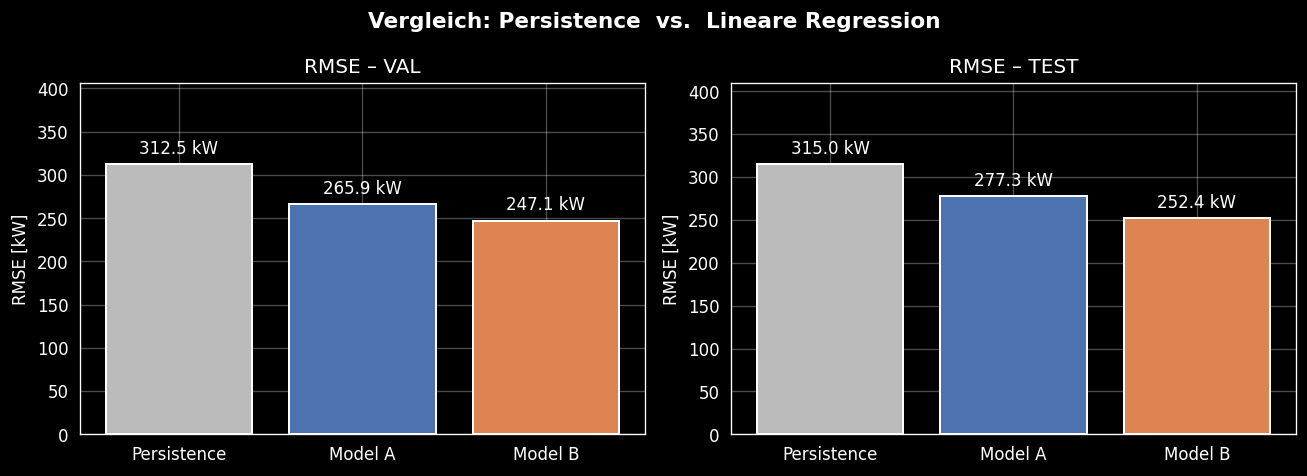

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, split, models, labels in [
    (
        axes[0], "VAL",
        ["Persistence (val)", "Model A – kein Lag (val)", "Model B – + lag96 (val)"],
        ["Persistence", "Model A", "Model B"],
    ),
    (
        axes[1], "TEST",
        ["Persistence (test)", "Model A – kein Lag (test)", "Model B – + lag96 (test)"],
        ["Persistence", "Model A", "Model B"],
    ),
]:
    vals   = [results_df.loc[m, "rmse"] for m in models]
    colors = ["#bbb", "#4C72B0", "#DD8452"]
    bars   = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.1f kW", padding=4, fontsize=10)
    ax.set_title(f"RMSE – {split}", fontsize=12)
    ax.set_ylabel("RMSE [kW]")
    ax.set_ylim(0, max(vals) * 1.3)

plt.suptitle("Vergleich: Persistence  vs.  Lineare Regression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Beispielwoche

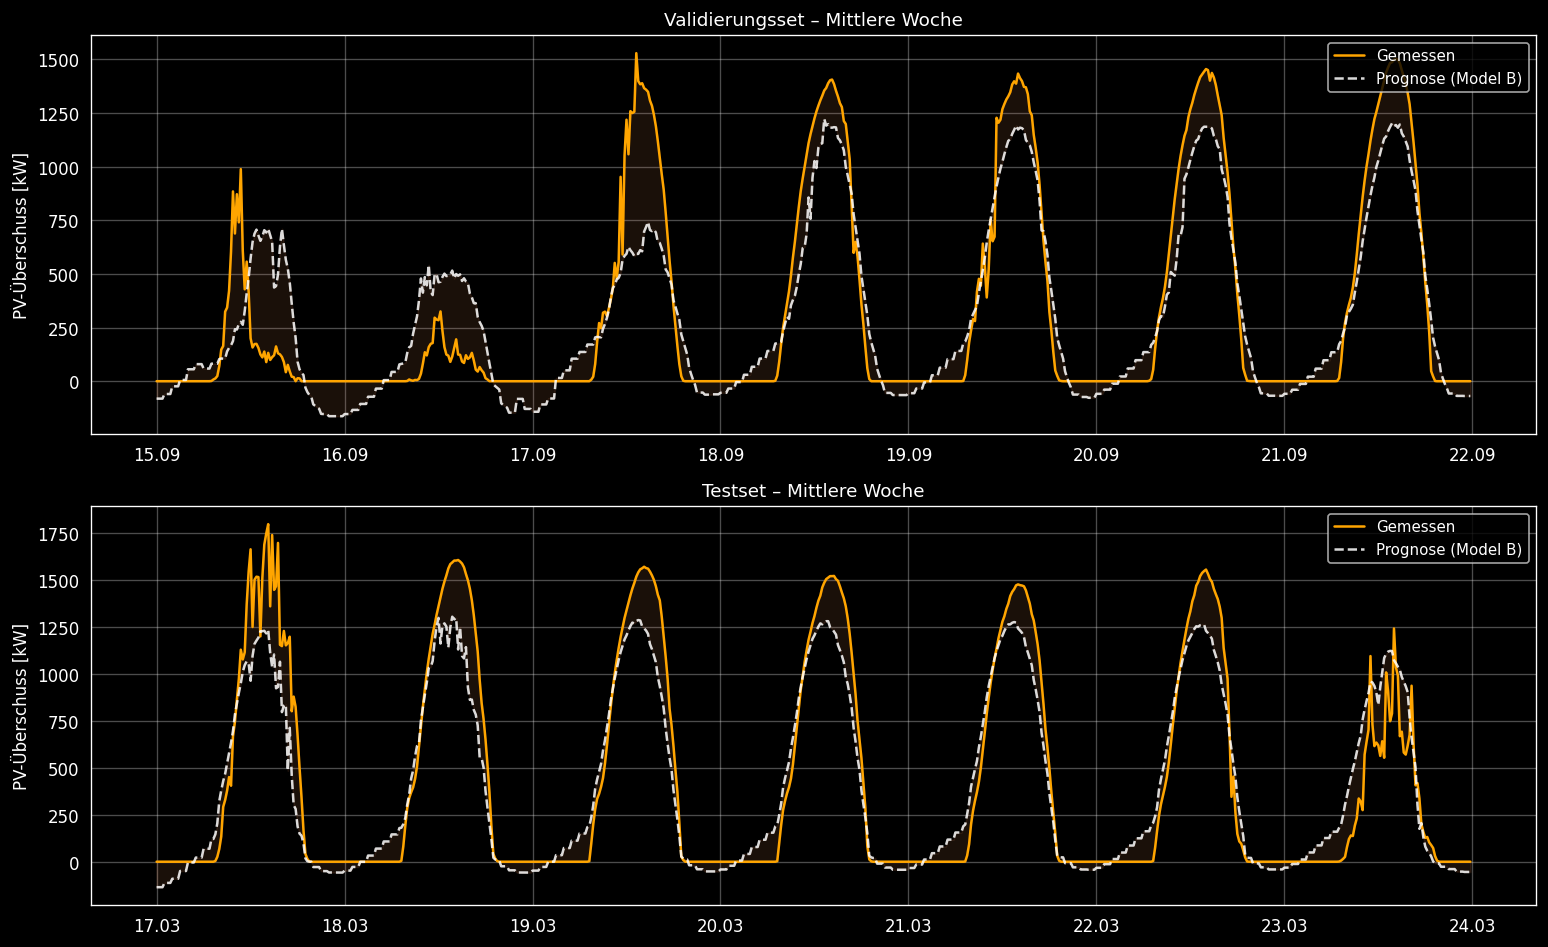

In [21]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split["timestamp"].iloc[len(df_split) // 2].floor("D")
    mask = (df_split["timestamp"] >= mid) & (
           df_split["timestamp"] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index("timestamp")
    pred = y_pred.reindex(sub.index)

    ax.plot(sub.index, sub[TARGET], label="Gemessen",
            color="orange", linewidth=1.5)
    ax.plot(sub.index, pred, label="Prognose (Model B)",
            color="white", linewidth=1.5, linestyle="--", alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color="#DD8452")
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc="upper right", fontsize=9)
    ax.set_ylabel("PV-Überschuss [kW]")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  "Validierungsset – Mittlere Woche")
plot_week(axes[1], test, pred_b_test, "Testset – Mittlere Woche")
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

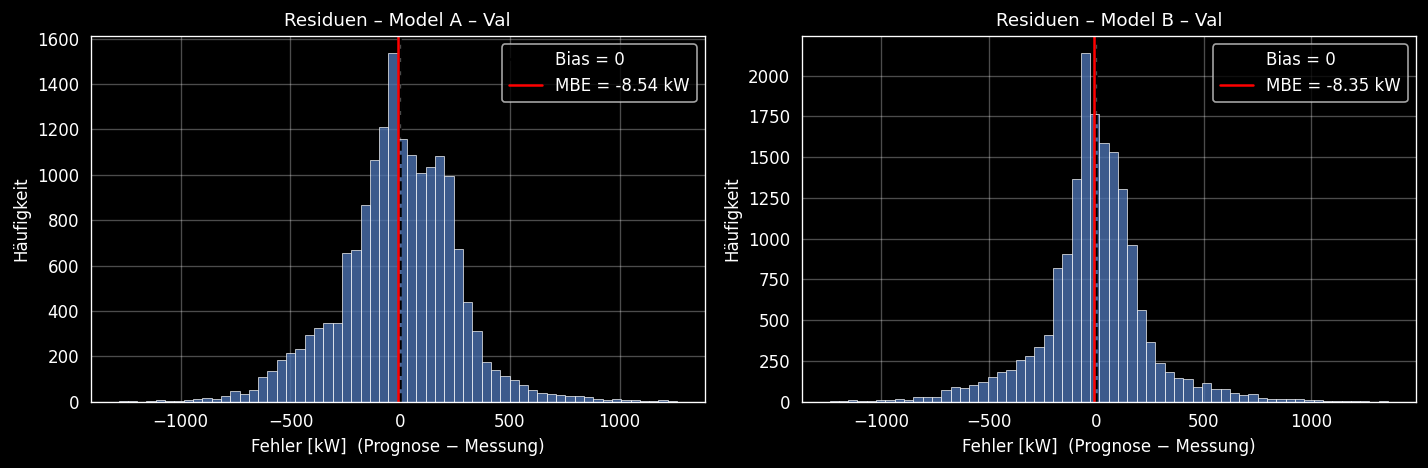

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], "Model A – Val", y_val, pred_a_val),
    (axes[1], "Model B – Val", y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color="#4C72B0", edgecolor="white",
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,           color="black", lw=1.5, ls="--", label="Bias = 0")
    ax.axvline(res.mean(),  color="red",   lw=1.5, ls="-",
               label=f"MBE = {res.mean():.2f} kW")
    ax.set_title(f"Residuen – {name}", fontsize=11)
    ax.set_xlabel("Fehler [kW]  (Prognose − Messung)")
    ax.set_ylabel("Häufigkeit")
    ax.legend()

plt.tight_layout()
plt.show()

## 8 · Forschungshypothesen

| Hypothese | Aussage | Ergebnis |
|---|---|---|
| **H2** | Wetter + Strahlung → RMSE < Persistence | Skill Score (MAE) > 0? |
| **H3** | Vortagswert (lag₉₆) verbessert Prognose | Model B > Model A? |
| **H4** | Nichtlinear > Linear | → Nächste Notebooks |

In [23]:
sk_a      = results_df.loc["Model A – kein Lag (val)", "skill_mae"]
sk_b      = results_df.loc["Model B – + lag96 (val)",  "skill_mae"]
rmse_pers = results_df.loc["Persistence (val)",        "rmse"]
rmse_a    = results_df.loc["Model A – kein Lag (val)", "rmse"]
rmse_b    = results_df.loc["Model B – + lag96 (val)",  "rmse"]

print("══ H2 – Wetter/Strahlung vs. Persistence ══")
print(f"  RMSE: Persistence {rmse_pers:.1f} kW  →  Model A {rmse_a:.1f} kW")
print(f"  Skill MAE (Model A): {sk_a:+.1%}  {'✓ bestätigt' if sk_a > 0 else '✗ nicht bestätigt'}")
print()
print("══ H3 – Einfluss lag_96 ══")
print(f"  RMSE: Model A {rmse_a:.1f} kW  →  Model B {rmse_b:.1f} kW  (Δ = {rmse_b - rmse_a:+.1f} kW)")
print(f"  Skill MAE: A = {sk_a:+.1%}  |  B = {sk_b:+.1%}")

══ H2 – Wetter/Strahlung vs. Persistence ══
  RMSE: Persistence 312.5 kW  →  Model A 265.9 kW
  Skill MAE (Model A): -33.8%  ✗ nicht bestätigt

══ H3 – Einfluss lag_96 ══
  RMSE: Model A 265.9 kW  →  Model B 247.1 kW  (Δ = -18.8 kW)
  Skill MAE: A = -33.8%  |  B = -13.2%


## 9 · Ergebnisse speichern

In [24]:
for model_name, yp_val, yp_test, feats in [
    ("linear_regression_A", pred_a_val, pred_a_test, FEATURES_A),
    ("linear_regression_B", pred_b_val, pred_b_test, FEATURES_B),
]:
    out = {
        "model":    model_name,
        "features": feats,
        "val":      evaluate(y_val,  yp_val,  P_NOM, y_ref=pers_val),
        "test":     evaluate(y_test, yp_test, P_NOM, y_ref=pers_test),
    }
    path = RESULTS_DIR / f"{model_name}.json"
    with open(path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Gespeichert: {path.name}")

Gespeichert: linear_regression_A.json
Gespeichert: linear_regression_B.json
